**Table of contents**<a id='toc0_'></a>    
- [Introduction](#toc1_)    
- [Loading Data](#toc2_)    
- [Description of tool for analyze features](#toc3_)    
  - [SHAP values](#toc3_1_)    
    - [Miners Story](#toc3_1_1_)    
    - [Shapley Formula](#toc3_1_2_)    
    - [SHAP Connection](#toc3_1_3_)    
- [Model and features importance](#toc4_)    
  - [About interpretation Direct-like strategy](#toc4_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Introduction](#toc0_)

When training a model, we often want to analyze which features stand out as important. This allows you to view the model not as a black box, but to understand how it interprets the data. This approach helps not only to interpret the results, but also to think of ways to create additional features to improve the model.

In our library, we provide convenient tools for this: calculating SHAP values or using the built-in importance function from CatBoost. Next, we'll explain how this works in practice and show you some examples.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from typing import List, Optional, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
shap.initjs()

from tsururu.dataset import Pipeline, TSDataset
from tsururu.model_training import MLTrainer
from tsururu.model_training import KFoldCrossValidator
from tsururu.models.boost import CatBoost
from tsururu.strategies import RecursiveStrategy, DirectStrategy

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
def plot_ts(y, lags):
    _, ax = plt.subplots(3, 1, figsize=(20,15))
    ax[0].plot(y[:100])
    ax[0].set_title('Time series')
    ax[0].set_xlabel('time')
    ax[0].set_ylabel('value')

    plot_pacf(y, ax=ax[1], lags=lags)
    ax[1].set_xticks(range(lags+1)) 
    ax[1].grid(True, axis='x')
    ax[1].set_xlabel('lag')
    ax[1].set_ylabel('pacf')

    plot_acf(y, ax=ax[2], lags=lags)
    ax[2].set_xticks(range(lags+1)) 
    ax[2].grid(True, axis='x')
    ax[2].set_xlabel('lag')
    ax[2].set_ylabel('acf')

    plt.show()

def split_data(df, horizon):
    train_df = df.iloc[:-horizon]
    test_df = df.iloc[-horizon:] 
    return train_df, test_df

# <a id='toc2_'></a>[Loading Data](#toc0_)

,Month,Passengers,id
0,1949-01,112,0
1,1949-02,118,0
2,1949-03,132,0
3,1949-04,129,0
4,1949-05,121,0


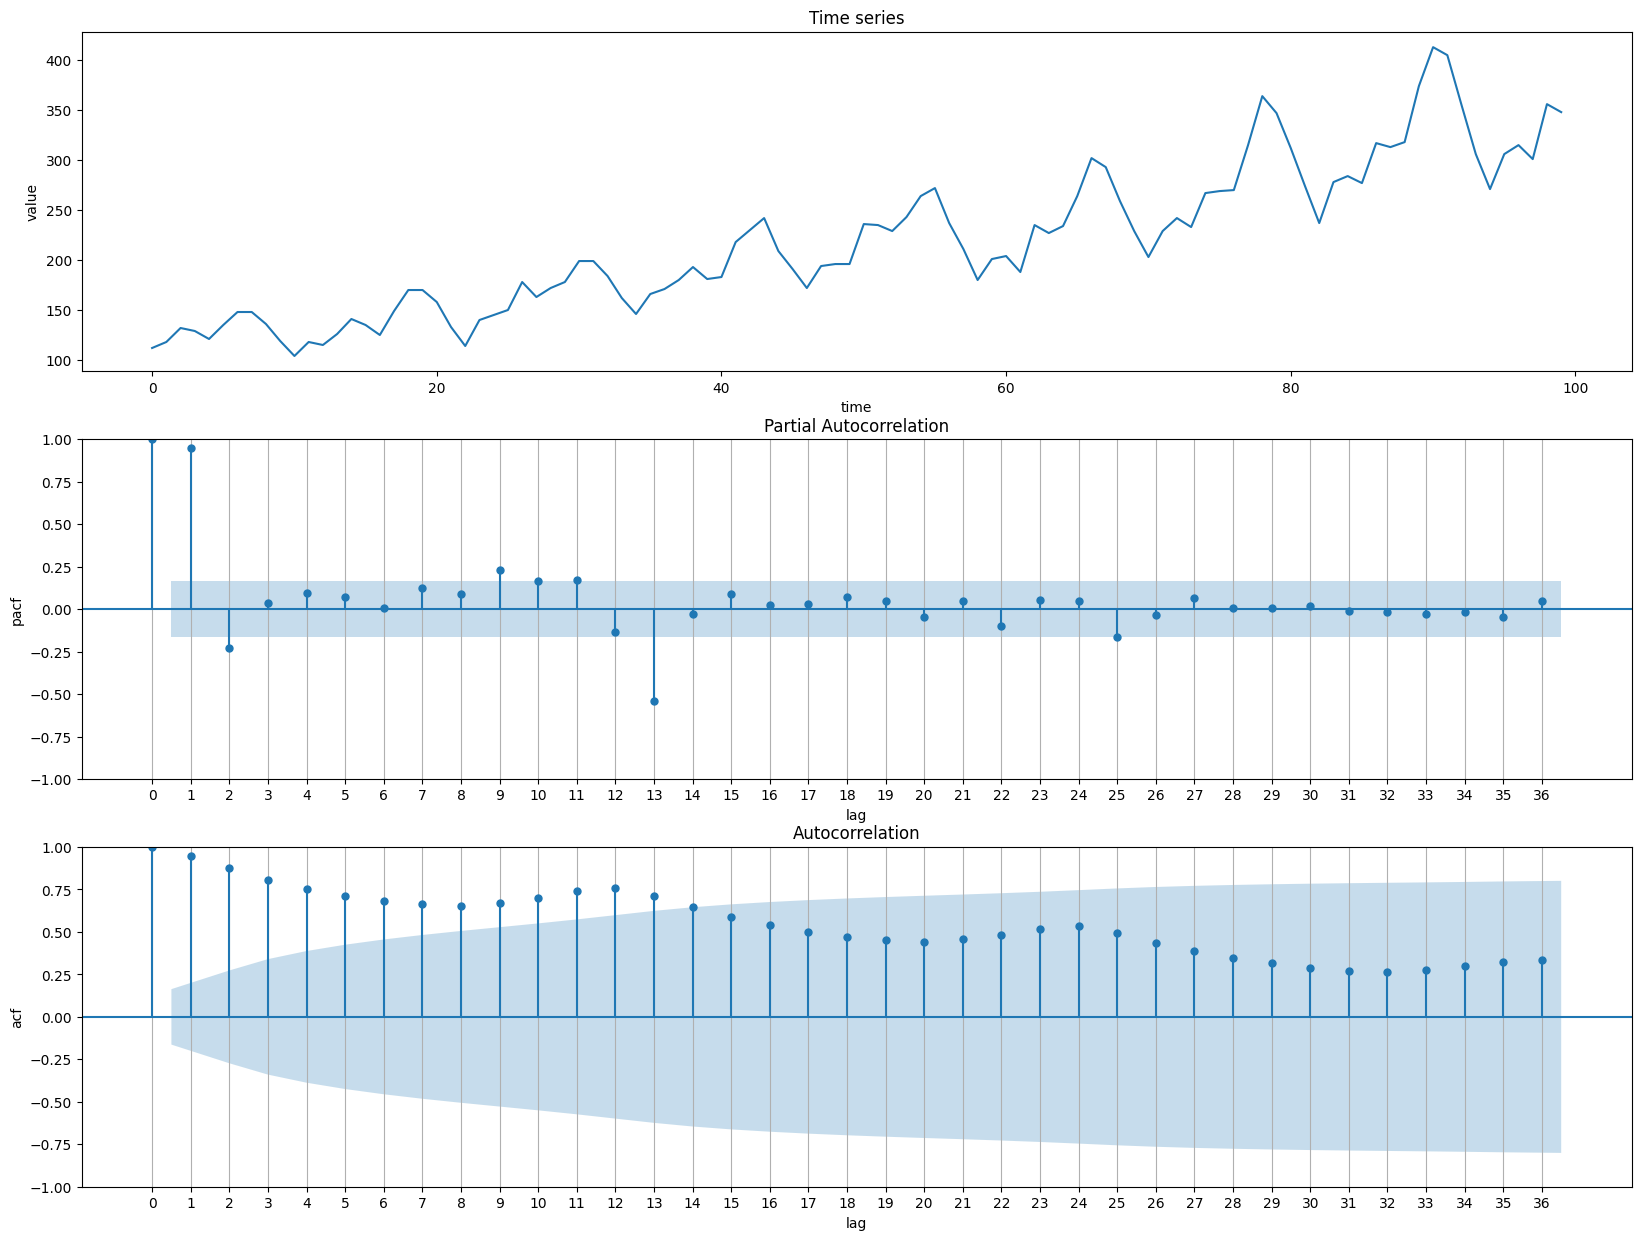

In [3]:
df = pd.read_csv('../datasets/global/AirPassengers.csv')
df['id'] = 0
display(df.head())
TARGET_COL = "Passengers"
TIME_COL = "Month"
ID_COL = "id"

plot_ts(y=df[TARGET_COL], lags=36)

Let’s take a look at how the time series looks. First of all, we need to visualize it by plotting the series values over time. Usually, from this graph it becomes clear whether there is a) a trend, b) cyclicity, and c) pronounced seasonality—for example, recurring peaks and troughs every 12 months for monthly data or every 7 days for daily data.  

After plotting the time series itself, we examine the autocorrelation function (ACF) and the partial autocorrelation function (PACF). The ACF shows how strongly the current value of the series is correlated with its past values at different lags (for example, $(x_t)$ with $(x_{t-1}, x_{t-2}, \dots)$).  

- If there are clear spikes in the ACF at regular intervals (for example, at lags 12, 24, 36 for monthly data), this is a strong sign of seasonality.  
- PACF helps us understand how many “pure” autoregressive lags are actually present in the series, cutting out intermediaries; it is useful for selecting the order of the AR component in ARIMA models.

The graph shows a real time series — the number of air passengers from the [Air Passengers](https://www.kaggle.com/datasets/chirag19/air-passengers )

In [4]:
HISTORY = 12
HORIZON = 12

dataset_param = {
    "target": {
        "columns": [TARGET_COL],
        "type": "continuous",
    },
    "date": {
        "columns": [TIME_COL],
        "type": "datetime",
    },
    "id": {
        "columns": [ID_COL],
        "type": "categorical",
    },
}

train_df, test_df = split_data(df=df, horizon=HORIZON)

train_dataset = TSDataset(
    data=train_df,
    columns_params=dataset_param,
    print_freq_period_info=True,
)

test_dataset = TSDataset(
    data=test_df,
    columns_params=dataset_param,
    print_freq_period_info=True,
)

freq: Month; period: 1.0
freq: Month; period: 1.0


In [5]:
pipeline_params = {
    "target": {
        "columns": [TARGET_COL],
        "features": {
            "LagTransformer": {"lags": HISTORY},
            "LastKnownNormalizer":
                {
                    "transform_target": True, 
                    "transform_features": True,
                    "regime": "ratio"
                },
        },
    },
    "date": {
        "columns": [TIME_COL],
        "features": {
            "DateSeasonsGenerator": {
                "seasonalities": ['doy', 'm', 'wd'], 
                "from_target_date": True,
            },
            "LagTransformer": {"lags": 1}
        },
    },
    "id": {
        "columns": [ID_COL],
        "features": {
            "LagTransformer": {"lags": 1},
        },
    }
}

In [6]:
pipeline = Pipeline.from_dict(pipeline_params, multivariate=False)

# <a id='toc3_'></a>[Description of tool for analyze features](#toc0_)

## <a id='toc3_1_'></a>[SHAP values](#toc0_)

### <a id='toc3_1_1_'></a>[Miners Story](#toc0_)
Three miners—Ivan, Petr, and Sergey—work in a coal mine. 

**Individual productivity**:  
Ivan alone extracts 0.1 tons/day, similarly for Petr and Sergey.

**Pairwise synergy**:  
Ivan+Petr = 0.4 tons (faster tunnel digging)  
Ivan+Sergey = 0.3 tons  
Petr+Sergey = 0.3 tons  

**Full team**: 1 ton/day (complete shift output).

Shapley values divide the 1 ton by averaging each miner's **marginal contribution** across all possible coalitions.

| Miner  | Shapley Value |
|--------|---------------|
| Ivan   | 0.383 tons    |
| Petr   | 0.308 tons    |
| Sergey | 0.308 tons    |
| **Sum**| **1.000 tons**|

**Ivan contributes more** when paired with Petr (their best synergy), but his **average contribution** across all coalitions is 0.383 tons. Petr and Sergey each receive 0.308 tons.

### <a id='toc3_1_2_'></a>[Shapley Formula](#toc0_)
The Shapley value for player $i $ is the weighted average of their marginal contribution over all subsets $S $ excluding $i $:

$$
\varphi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (n - |S| - 1)!}{n!} \left( v(S \cup \{i\}) - v(S) \right)
$$

where $n$ is the number of players (miners), and $v(S) $ is the output of coalition $S $. The weight $\frac{|S|! (n - |S| - 1)!}{n!} $ equals the probability of $i $ joining after $S $.

This averages contributions: imagine all $n! $ orders of team formation—for each, compute the marginal gain $v(P_i^R \cup \{i\}) - v(P_i^R) $ (where $P_i^R $ are predecessors of $i $), then take the mean.

### <a id='toc3_1_3_'></a>[SHAP Connection](#toc0_)
SHAP (SHapley Additive exPlanations) applies this to ML: features are "miners," model prediction is "output." The SHAP value $\phi_i $ shows feature $i $'s contribution to a specific prediction, averaging over feature coalitions.

For example, in a crop yield model, SHAP explains why "rain" added +0.2 tons to the forecast, considering all factor combinations. It is the unique method satisfying efficiency, symmetry, additivity, and null player axioms.

# <a id='toc4_'></a>[Model and features importance](#toc0_)

In [7]:
# Configure the model parameters
model = CatBoost
model_params = {
    "loss_function": "MultiRMSE",
    "early_stopping_rounds": 100,
    "verbose": 500,
}

# Configure the validation parameters
validation = KFoldCrossValidator
validation_params = {
    "n_splits": 4,
}

trainer = MLTrainer(
    model,
    model_params,
    validation,
    validation_params,
    return_importance=True
)

strategy_recurs = RecursiveStrategy(HORIZON, HISTORY, trainer, pipeline)

In [8]:
fit_time_real, _ = strategy_recurs.fit(train_dataset)

_, current_pred_recurs = strategy_recurs.predict(train_dataset)

0:	learn: 0.1074622	test: 0.1050593	best: 0.1050593 (0)	total: 46.1ms	remaining: 46.1s
500:	learn: 0.0064693	test: 0.0479134	best: 0.0478602 (492)	total: 185ms	remaining: 184ms
999:	learn: 0.0011936	test: 0.0474754	best: 0.0474641 (911)	total: 331ms	remaining: 0us

bestTest = 0.04746409041
bestIteration = 911

Shrink model to first 912 iterations.
Fold 0. Score: 0.04746409041282598
0:	learn: 0.1091236	test: 0.0985219	best: 0.0985219 (0)	total: 430us	remaining: 430ms
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.04199828793
bestIteration = 209

Shrink model to first 210 iterations.
Fold 1. Score: 0.041998287930521856
0:	learn: 0.1026947	test: 0.1182497	best: 0.1182497 (0)	total: 403us	remaining: 403ms
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.04358872564
bestIteration = 361

Shrink model to first 362 iterations.
Fold 2. Score: 0.043588725635574185
0:	learn: 0.1071651	test: 0.1059900	best: 0.1059900 (0)	total: 437us	remaining: 437ms
500:	

If you want to calculate SHAP values for the strategy, you need to set the corresponding parameters in the `trainer`. For example:

```python
trainer = MLTrainer(
    ...
    return_importance=True
)
```

After that, the following method becomes available:

```python
get_feature_importance(
    top_k=5,
    aggregate_by_folds=True,
    return_explainer=True,
    round_to=4
)
```

About the parameters:

- `top_k`: Select the top `k` features by SHAP value (ranked by absolute importance).  
- `aggregate_by_folds`: Whether to aggregate the SHAP values across all CV folds (`True`) or keep them per fold (`False`).  
- `return_explainer`: If set to `True`, the method returns a fitted SHAP explainer object, which you can use with the [shap](https://shap.readthedocs.io/en/latest/index.html) library for more detailed analysis (e.g., dependence plots, interaction effects, etc.).  
- `round_to`: The number of decimal places to round all SHAP values and derived importance metrics to.

If you need the raw SHAP values directly, you can use the following methods:

- `get_train_shap()`: Returns SHAP values for the training data.
- `get_test_shap()`: Returns SHAP values for the test (or hold‑out) data.

These methods are useful if you want to analyze feature effects per instance, inspect the sign and magnitude of individual contributions, or build custom visualizations (e.g., SHAP summary plots, force plots, or waterfall plots) outside of the trainer’s built‑in feature‑importance interface.

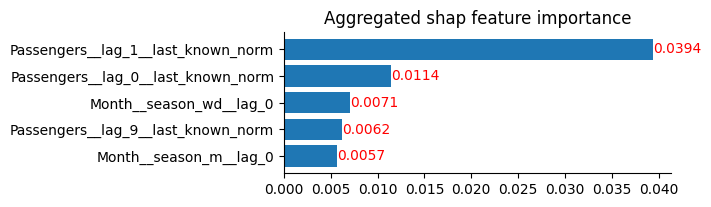

In [9]:
explain = strategy_recurs.get_feature_importance(top_k=5, aggregate_by_folds=True, return_explainer=True, round_to=4)

**Note:** The `aggregate_by_folds` parameter defines the type of visualization and the method of aggregating SHAP values:
- If `aggregate_by_folds=True` (default): \
The method aggregates the SHAP values for all the folds of the cross validation into average values. \
Result: horizontal barplots (barh) showing the top K features, sorted by the average absolute SHAP value.
- If `aggregate_by_folds=False`:\
SHAP, the values are stored separately for each CV fold. \
Result: boxplots for the same top-K features, sorted by average value by folds. \
    Boxplots show the spread of feature importance between folds — median, quartiles, and outliers.

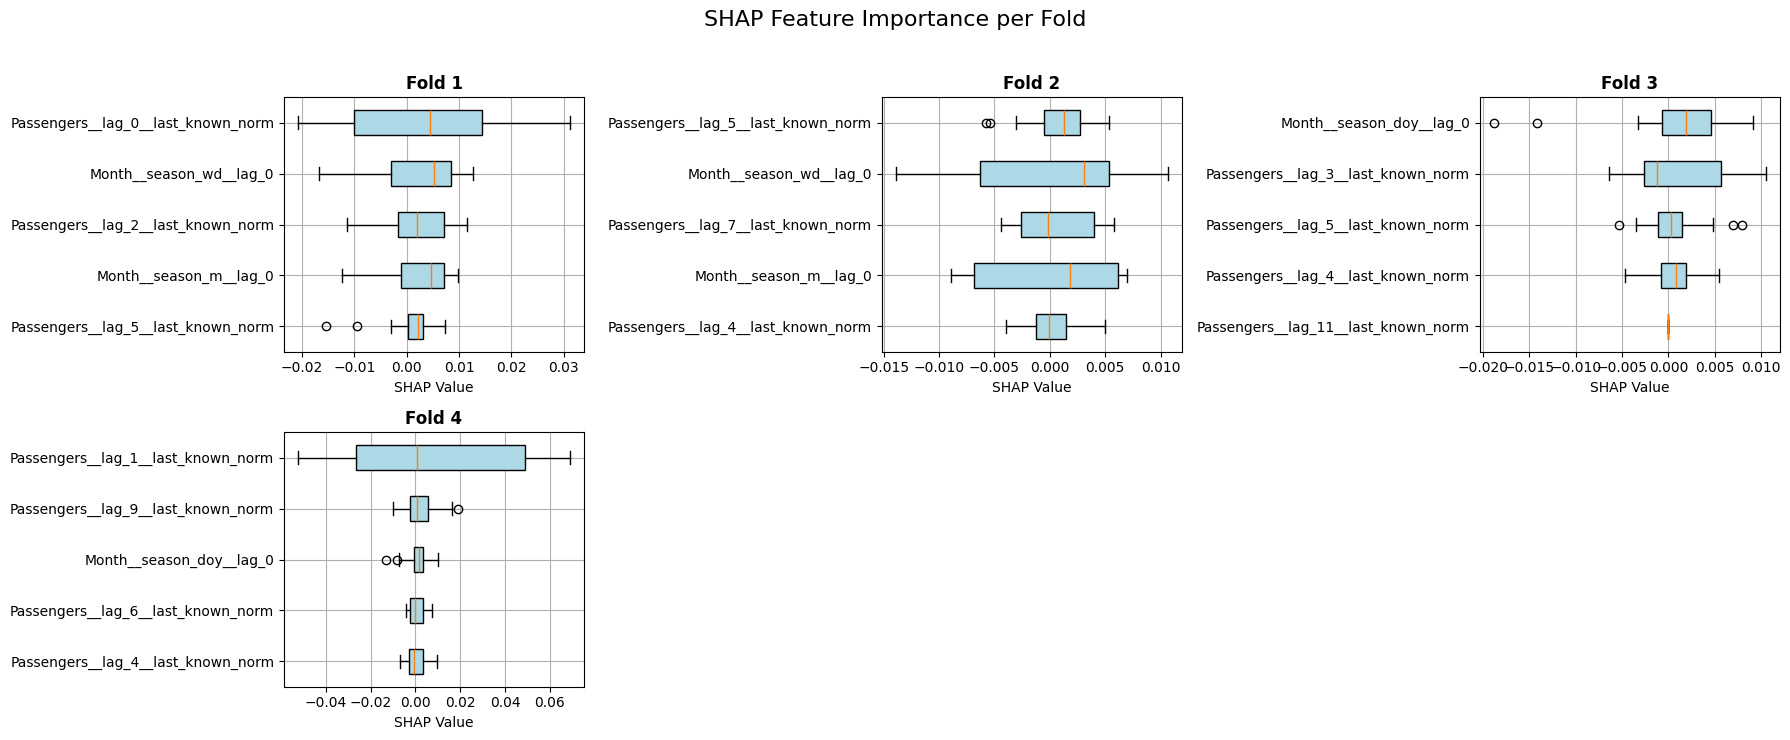

In [10]:
strategy_recurs.get_feature_importance(top_k=5, aggregate_by_folds=False)

**IMPORTANT**: Before examining these graphs and drawing conclusions about feature importance, make sure your model is **not** overfitting. You can check this by measuring performance metrics on a validation set.

**Note:** The SHAP graphs below are interactive JavaScript visualizations. On GitHub, they appear as static screenshots since the platform blocks JS execution. Local execution works fully

In [ ]:
shap.plots.waterfall(explain[12], max_display=5)

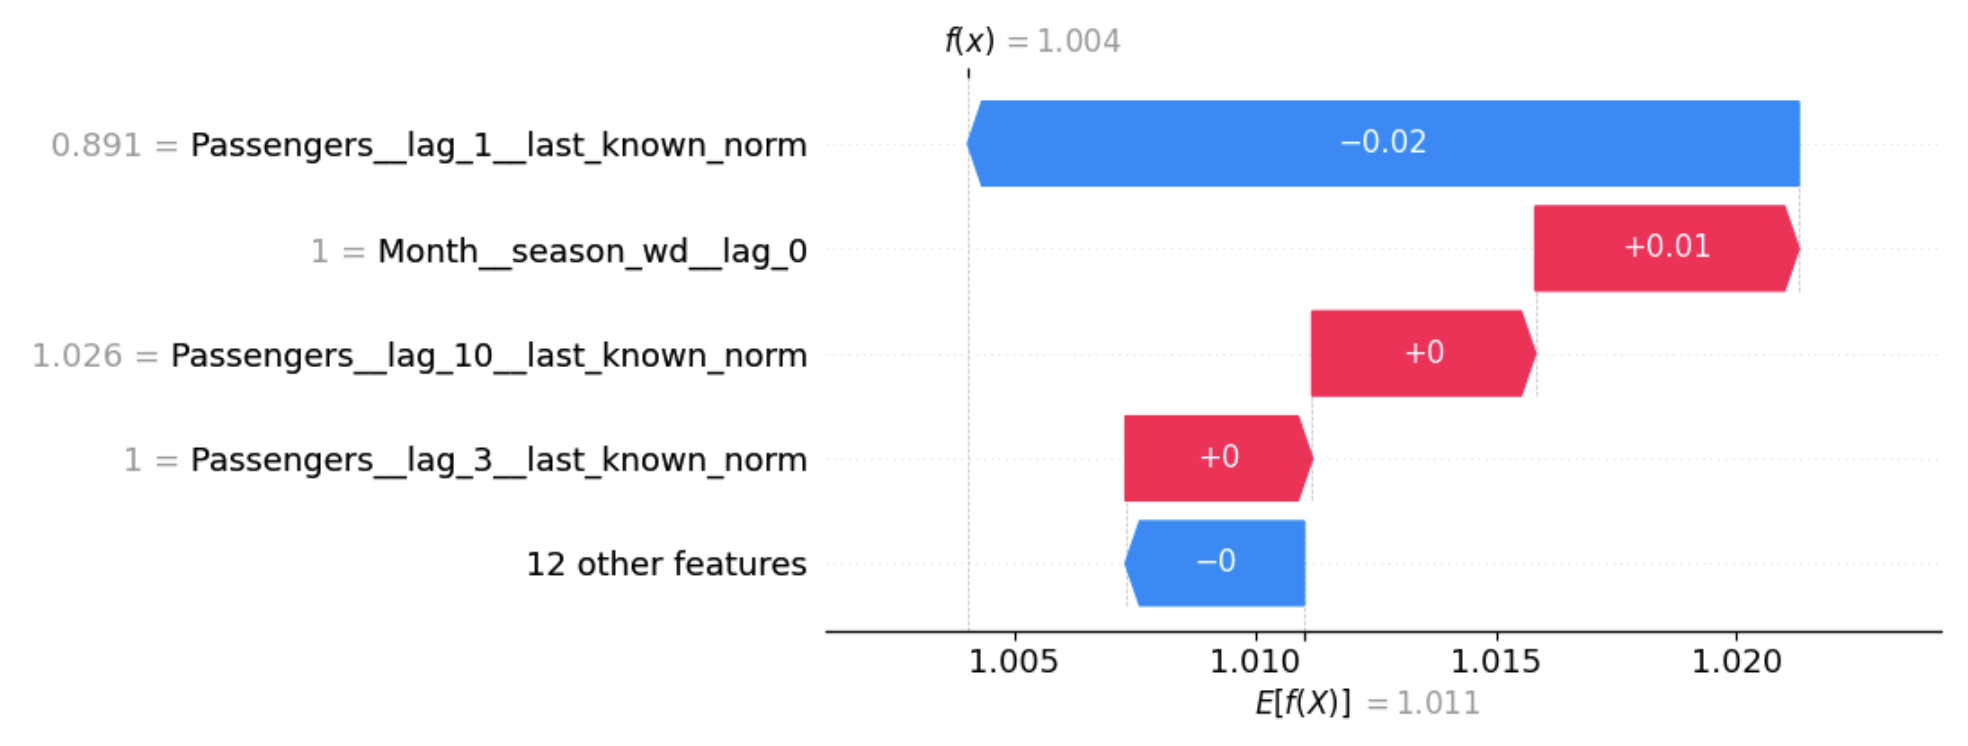

SHAP force plots visualize how individual feature values $(x_i)$ push a model's prediction $(f(x))$ away from the average base value $(\mathbb{E}[f(x)])$. Red bars indicate features increasing the prediction (higher risk/value), while blue bars show features decreasing it. The plot length corresponds to the magnitude of each feature's impact

In [ ]:
display(shap.plots.force(explain[:150]))

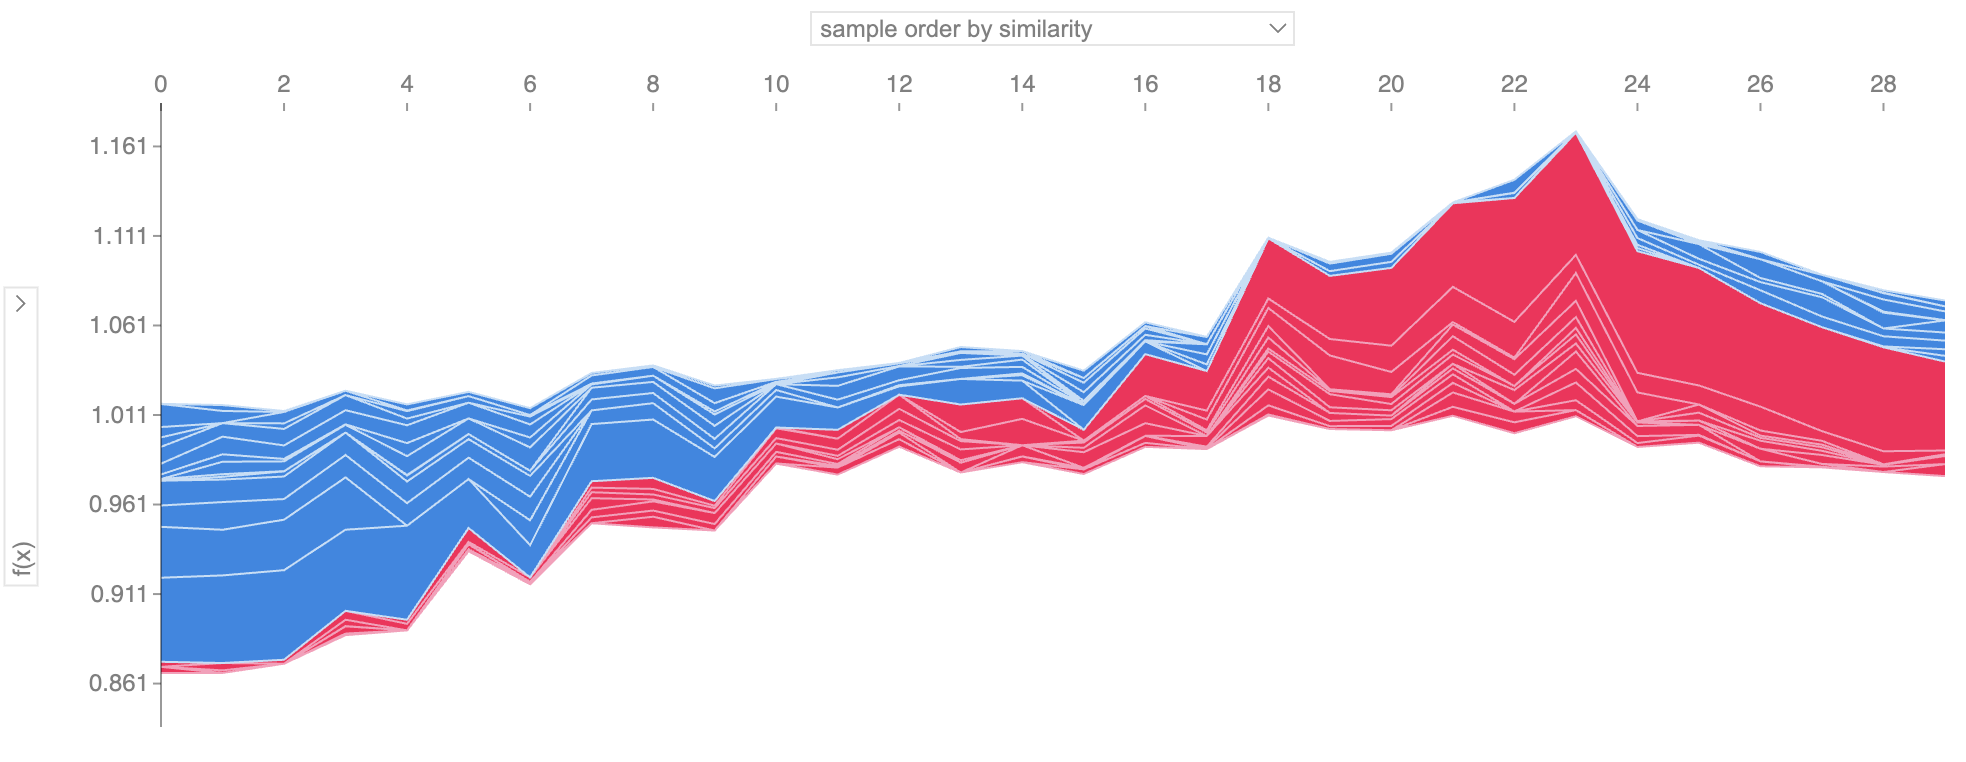

On this plot we see essentially the same information as above, but now we stack many samples on a single visualization. This allows us to see how different samples are influenced by the same set of features at once, while still preserving the intuitive representation of each instance as a horizontal “force” plot.

When you feed an array into `shap.plots.force`, SHAP automatically arranges the individual force plots vertically, one below the other. Each row corresponds to one sample, where the base value (the model’s expected output) is shown on the left, and the final prediction for that sample is on the right. Features that push the prediction higher (positive SHAP values) are shown in red and move the bar to the right, while features that lower the prediction (negative SHAP values) are shown in blue and move the bar to the left.

By stacking multiple samples, you can quickly spot common patterns across the dataset. For example, you may notice that certain features consistently have large positive or negative impacts across many instances, indicating globally important drivers of the model’s decisions. At the same time, you can also see cases where the prediction is driven by very different feature combinations, which helps reveal heterogeneity in the model behavior and potential context‑specific effects.

This kind of visualization is especially useful when you want to:

- Compare how the same model behaves on different subgroups (e.g., different time periods, user segments, or risk buckets).  
- Investigate borderline or misclassified samples and see whether similar features are responsible for their predictions.  
- Present model explanations to non‑technical stakeholders in a compact, side‑by‑side format.

## <a id='toc4_1_'></a>[About interpretation Direct-like strategy](#toc0_)

The direct model differs from the recursive one in that in the recursive one, one model predicts the next step and iteratively expands the forecast, while the direct one uses independent models for each horizon.

This strategy involves training separate models for each step of the forecast (the "model horizon"), which allows you to build a complete forecast horizon without iterative dependencies on previous forecasts.

Therefore, working with the shap instance will be different. expliner will have the form `n_sample` $\times$ `n_feature` $\times$ `n_models`

Let's show you how to work with expliner in this case.

In [11]:
strategy_direct = DirectStrategy(HORIZON, HISTORY, trainer, pipeline, model_horizon=6)

fit_time_real_direct, _ = strategy_direct.fit(train_dataset)
_, current_pred_real_direct = strategy_direct.predict(train_dataset)

0:	learn: 0.4912560	test: 0.4539859	best: 0.4539859 (0)	total: 1.89ms	remaining: 1.89s
500:	learn: 0.0296011	test: 0.1857418	best: 0.1856774 (490)	total: 333ms	remaining: 331ms
999:	learn: 0.0082430	test: 0.1840814	best: 0.1840765 (998)	total: 655ms	remaining: 0us

bestTest = 0.1840764724
bestIteration = 998

Shrink model to first 999 iterations.
Fold 0. Score: 0.18407647240190148
0:	learn: 0.4686391	test: 0.5256829	best: 0.5256829 (0)	total: 1.03ms	remaining: 1.03s
500:	learn: 0.0327608	test: 0.1272856	best: 0.1272856 (500)	total: 325ms	remaining: 324ms
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.127034592
bestIteration = 723

Shrink model to first 724 iterations.
Fold 1. Score: 0.12703459196136616
0:	learn: 0.4840875	test: 0.4784709	best: 0.4784709 (0)	total: 1.33ms	remaining: 1.33s
500:	learn: 0.0335421	test: 0.1473746	best: 0.1473621 (497)	total: 321ms	remaining: 320ms
999:	learn: 0.0096792	test: 0.1459147	best: 0.1459039 (997)	total: 643ms	remaining: 0us



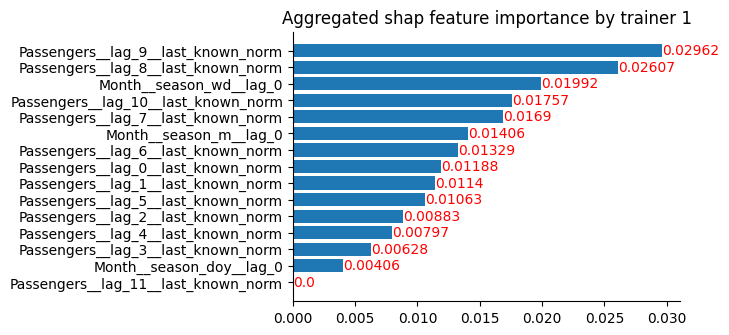

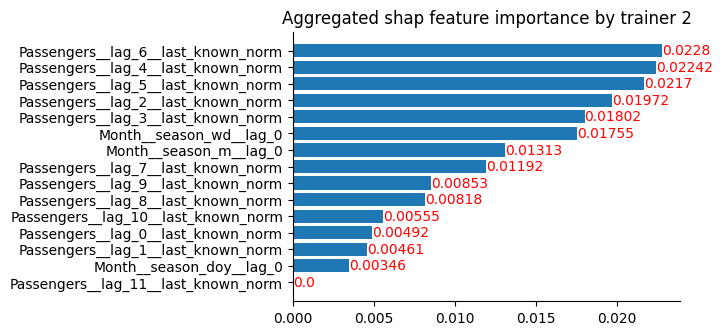

In [12]:
explain_direct = strategy_direct.get_feature_importance(top_k=15, return_explainer=True, aggregate_by_folds=True, round_to=5)

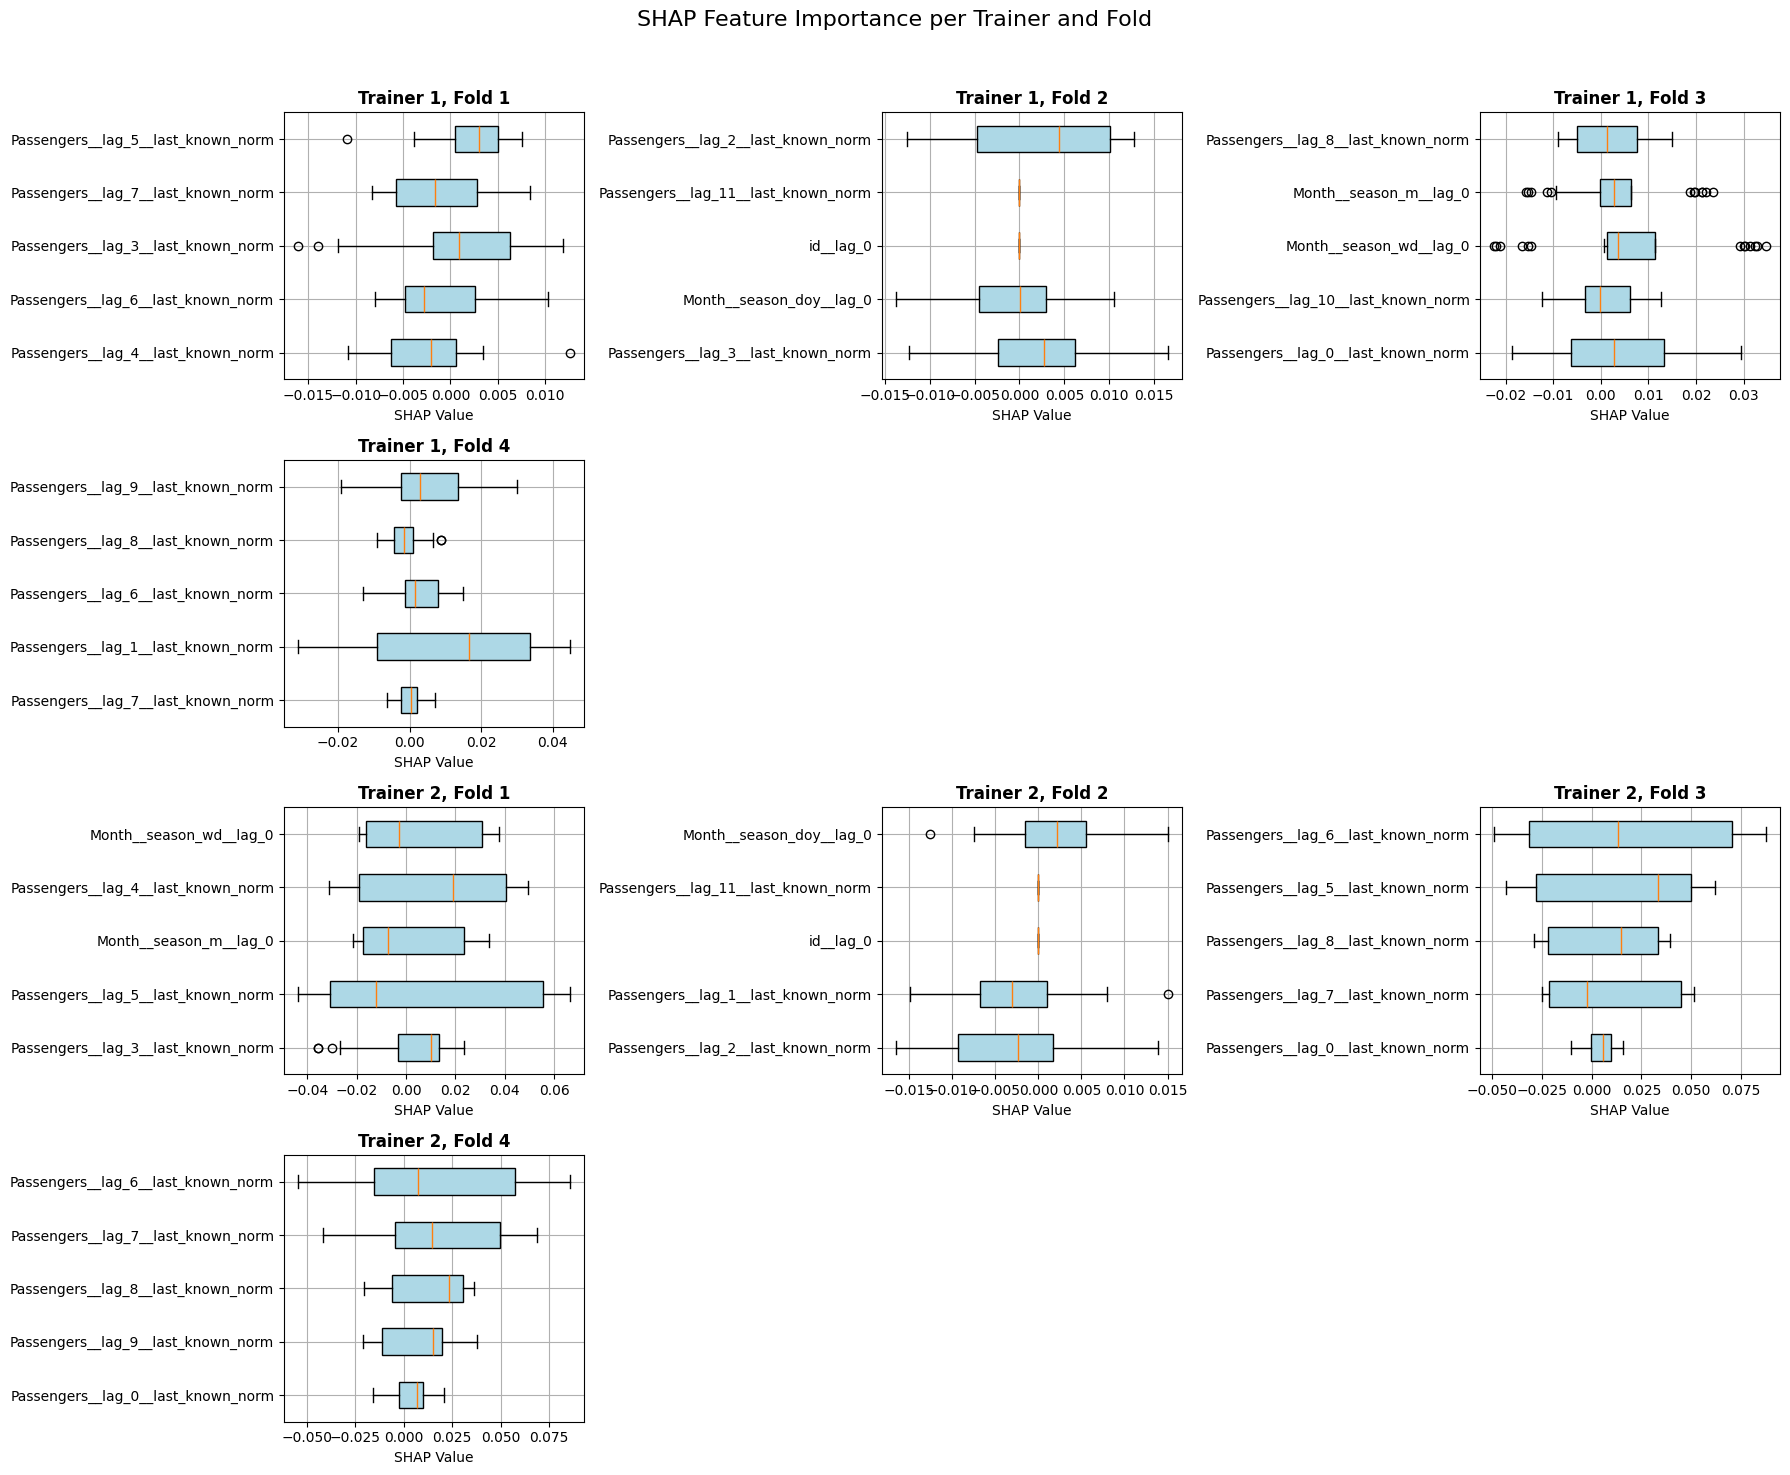

In [13]:
strategy_direct.get_feature_importance(top_k=5, return_explainer=False, aggregate_by_folds=False, round_to=5)

In [ ]:
display(shap.plots.force(explain_direct[0][:,:,0]))

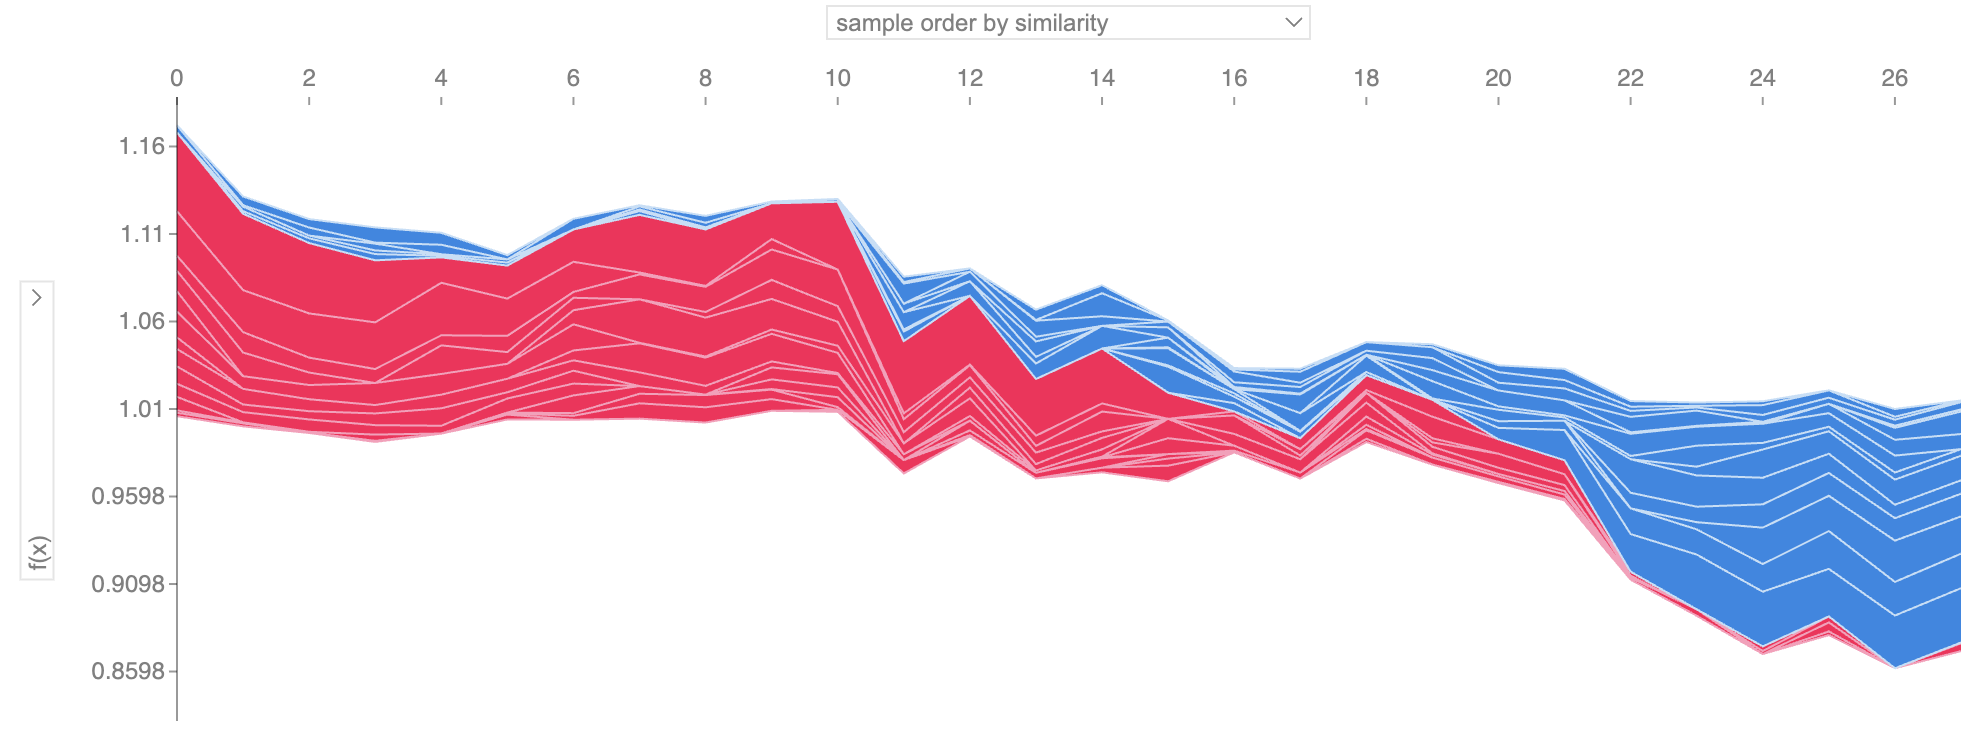

Well, let's look at how our models have been predicted.

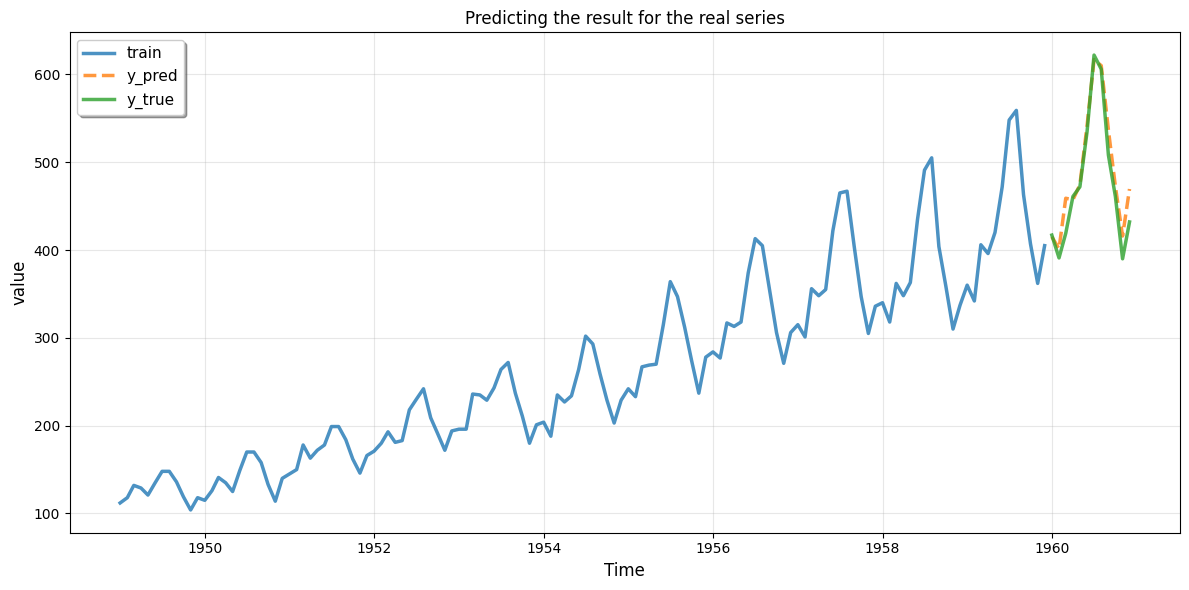

In [14]:
y_pred = current_pred_recurs[TARGET_COL]
x_pred = current_pred_recurs[TIME_COL]
y_true_real = test_df[TARGET_COL]
x_true_real = test_df[TIME_COL]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train_df[TIME_COL], train_df[TARGET_COL], linewidth=2.5, markersize=4, 
             alpha=0.8, label='train')
ax.plot(x_pred, y_pred, linewidth=2.5, markersize=4, ls='--',
             alpha=0.8, label='y_pred')
ax.plot(x_true_real, y_true_real, linewidth=2.5, markersize=4, 
             alpha=0.8, label='y_true')

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('value', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8)
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True, fontsize=11)
ax.set_title("Predicting the result for the real series")

plt.tight_layout()
plt.show()